## Simran Amesar

## Matriculation number - 100007050

In [105]:
texts = [
    "This phone is excellent",
    "Amazing battery life",
    "Very fast performance",
    "Camera quality is great",
    "I love this laptop",
    "Terrible customer service",
    "Battery drains quickly",
    "Very slow device",
    "Worst phone ever",
    "I hate this product",
    "I like this product but it's not the best"
]

In [106]:
# 1 = Positive
# 0 = Negative

labels = [1,1,1,1,1,0,0,0,0,0,1]

In [107]:
import numpy as np

from gensim.models import Word2Vec

In [108]:
tokenized_texts = [
    text.lower().split()
    for text in texts
]

In [109]:
print(tokenized_texts)

[['this', 'phone', 'is', 'excellent'], ['amazing', 'battery', 'life'], ['very', 'fast', 'performance'], ['camera', 'quality', 'is', 'great'], ['i', 'love', 'this', 'laptop'], ['terrible', 'customer', 'service'], ['battery', 'drains', 'quickly'], ['very', 'slow', 'device'], ['worst', 'phone', 'ever'], ['i', 'hate', 'this', 'product'], ['i', 'like', 'this', 'product', 'but', "it's", 'not', 'the', 'best']]


In [110]:
w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=50,
    window=3,
    min_count=1,
    workers=4,
    sg = 1
)

In [111]:
print(w2v_model.wv.index_to_key)

['this', 'i', 'product', 'very', 'battery', 'is', 'phone', 'best', 'the', 'not', "it's", 'but', 'like', 'hate', 'ever', 'worst', 'device', 'slow', 'quickly', 'drains', 'service', 'customer', 'terrible', 'laptop', 'love', 'great', 'quality', 'camera', 'performance', 'fast', 'life', 'amazing', 'excellent']


In [112]:
print(w2v_model.wv['excellent'])

[ 0.00260033 -0.01960861  0.00917553 -0.00107645  0.01266419  0.00356695
 -0.0062596   0.01551995  0.00310933  0.00011042 -0.00922591 -0.01690705
 -0.01553366  0.01734102 -0.01784992  0.01806943 -0.01856204 -0.00055351
 -0.00381409 -0.01786229  0.01726012  0.01355563  0.00603888  0.00966691
  0.00022438  0.01884936  0.01404257 -0.01970745 -0.00886644 -0.00258022
  0.00609545 -0.0086479   0.00289833 -0.0156918   0.00555615  0.00940538
  0.00987463 -0.0063514  -0.01685408 -0.01844124 -0.0014458  -0.01465493
 -0.01362993  0.01224001  0.01434461  0.00423484 -0.0157988  -0.01139798
  0.01610369  0.00784169]


In [113]:
print(
    w2v_model.wv.most_similar('excellent')
)

[('worst', 0.3173593282699585), ('this', 0.2406546175479889), ('the', 0.21870222687721252), ('customer', 0.2177131026983261), ('like', 0.18451760709285736), ('life', 0.1783401072025299), ('ever', 0.17044849693775177), ('performance', 0.13190807402133942), ('great', 0.12943966686725616), ('slow', 0.11862964183092117)]


In [114]:
def sentence_vector(sentence, model):

    words = sentence.lower().split()

    vectors = []

    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [115]:
X = np.array([
    sentence_vector(text, w2v_model)
    for text in texts
])

In [116]:
print(X.shape)

(11, 50)


In [117]:
import tensorflow as tf
from tensorflow.keras.models import Sequential # Builds the layers one by one
from tensorflow.keras.layers import Dense #creates a fully connected layer


In [118]:
model = Sequential() 
model.add(Dense(8,activation='relu',input_shape=(X.shape[1],)))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X,
    np.array(labels),
    epochs=15,
    verbose=1
)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 8)              │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.3636 - loss: 0.6930
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3636 - loss: 0.6927
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3636 - loss: 0.6923
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4545 - loss: 0.6919
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5455 - loss: 0.6916
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6364 - loss: 0.6913
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6364 - loss: 0.6911
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7273 - loss: 0.6908
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7273 - loss: 0.6905
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7273 - loss: 0.6903
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7273 - loss: 0.6901
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8182 - loss: 0.6900


In [131]:
test_sentence = "Amazing performance and excellent battery"

test_vector = sentence_vector(
    test_sentence,
    w2v_model
)

test_vector = test_vector.reshape(1, -1)

prediction = model.predict(test_vector)

print(prediction)

if prediction[0][0] > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[0.5030399]]
Positive Review


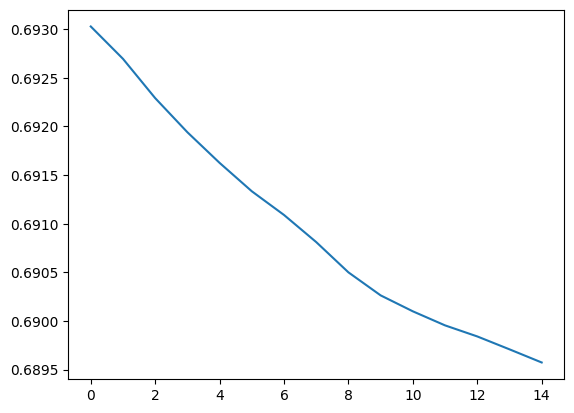

In [132]:
import matplotlib.pyplot as plt
# Training loss
plt.plot(history.history['loss'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


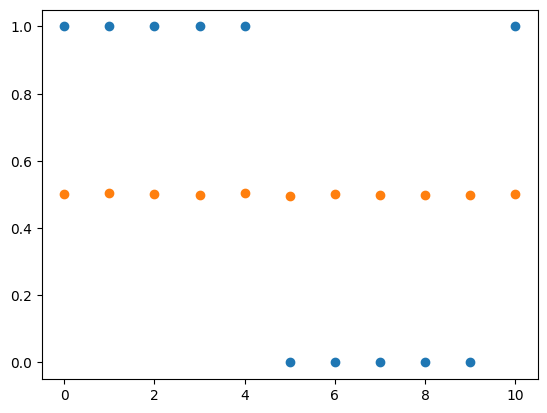

In [133]:
predictions = model.predict(X).flatten()

plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()